# **EXPERIMENT 4 : DATA WRANGLING AND DATA VISUALIZATION**

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

In [27]:
# Uploading the ECE Board Exam 2 dataset from the Excel File
bdf = pd.read_excel("board2.xlsx")
bdf

,Name,Gender,Track,Hometown,Math,Electronics,GEAS,Communication
0,S1,Male,Instrumentation,Luzon,58,89,75,78
1,S2,Female,Communication,Mindanao,52,75,90,52
2,S3,Female,Instrumentation,Mindanao,83,74,77,57
3,S4,Male,Instrumentation,Visayas,65,58,91,68
4,S5,Male,Communication,Luzon,59,86,43,88
5,S6,Female,Microelectronics,Visayas,88,45,86,83
6,S7,Female,Instrumentation,Luzon,66,60,60,48
7,S8,Male,Instrumentation,Luzon,49,81,64,53
8,S9,Male,Instrumentation,Luzon,50,36,63,42
9,S10,Male,Microelectronics,Mindanao,80,84,61,44


In [28]:
#Create the average column through the meran score
bdf["Average"] = bdf[['Math', 'Electronics', 'GEAS', 'Communication']].mean(axis=1)
bdf

,Name,Gender,Track,Hometown,Math,Electronics,GEAS,Communication,Average
0,S1,Male,Instrumentation,Luzon,58,89,75,78,75.00
1,S2,Female,Communication,Mindanao,52,75,90,52,67.25
2,S3,Female,Instrumentation,Mindanao,83,74,77,57,72.75
3,S4,Male,Instrumentation,Visayas,65,58,91,68,70.50
4,S5,Male,Communication,Luzon,59,86,43,88,69.00
5,S6,Female,Microelectronics,Visayas,88,45,86,83,75.50
6,S7,Female,Instrumentation,Luzon,66,60,60,48,58.50
7,S8,Male,Instrumentation,Luzon,49,81,64,53,61.75
8,S9,Male,Instrumentation,Luzon,50,36,63,42,47.75
9,S10,Male,Microelectronics,Mindanao,80,84,61,44,67.25


#**A. VISAYAS COMMUNICATION DATAFRAME**

In [29]:
#Create the dataframe named Viscomm with the following conditions: The student must be in Visayas and Their track must be in Communication
VisComm = bdf[(bdf["Hometown"] == "Visayas") &
          (bdf["Track"] == "Communication")][
#After filtering, retain only the required columns in the order:
          ["Name", "Gender", "Math", "Electronics", "Average"]]

#Display the Dataframe
VisComm

,Name,Gender,Math,Electronics,Average
10,S11,Female,48,56,54.75
11,S12,Male,89,67,76.00
17,S18,Male,81,40,63.50
21,S22,Female,64,39,62.50
27,S28,Male,85,53,67.75


In [30]:
#Count and display the number of rows in VisComm
print("Number of rows:", len(VisComm))

Number of rows: 5


#**B. VISAYAS FEMALE DATAFRAME**

In [31]:
#Create a Dataframe named VisW with the following conditions: The student must be in Visayas and must be a Female
VisW = bdf[(bdf["Hometown"] == "Visayas") &
          (bdf["Gender"] == "Female")][
#After filtering, retain only the required columns in the order:
          ["Name", "Track", "GEAS", "Electronics", "Average"]]

#Display Dataframe
VisW

,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,75.50
10,S11,Communication,48,56,54.75
20,S21,Microelectronics,68,51,68.50
21,S22,Communication,89,39,62.50
23,S24,Microelectronics,60,45,57.75
25,S26,Instrumentation,83,47,65.75


In [32]:
#Display VisW students with an Average of atleast 60 and above
VisW[VisW["Average"] >= 60]

,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,75.50
20,S21,Microelectronics,68,51,68.50
21,S22,Communication,89,39,62.50
25,S26,Instrumentation,83,47,65.75


#**C. CATEGORY-AVERAGE VISUALIZATION**

In [33]:
#Calculate the mean Average for each of the Track
avg_track = bdf.groupby("Track")["Average"].mean().reset_index()

avg_track

,Track,Average
0,Communication,67.975
1,Instrumentation,65.225
2,Microelectronics,67.500


In [34]:
#Calculate the Mean Average for each Gender
avg_gender = bdf.groupby("Gender")["Average"].mean().reset_index()

avg_gender

,Gender,Average
0,Female,66.616667
1,Male,67.183333


In [35]:
#Calculate the Mean Average for each Hometown
avg_hometown = bdf.groupby("Hometown")["Average"].mean().reset_index()

avg_hometown

,Hometown,Average
0,Luzon,68.083333
1,Mindanao,66.678571
2,Visayas,65.750000


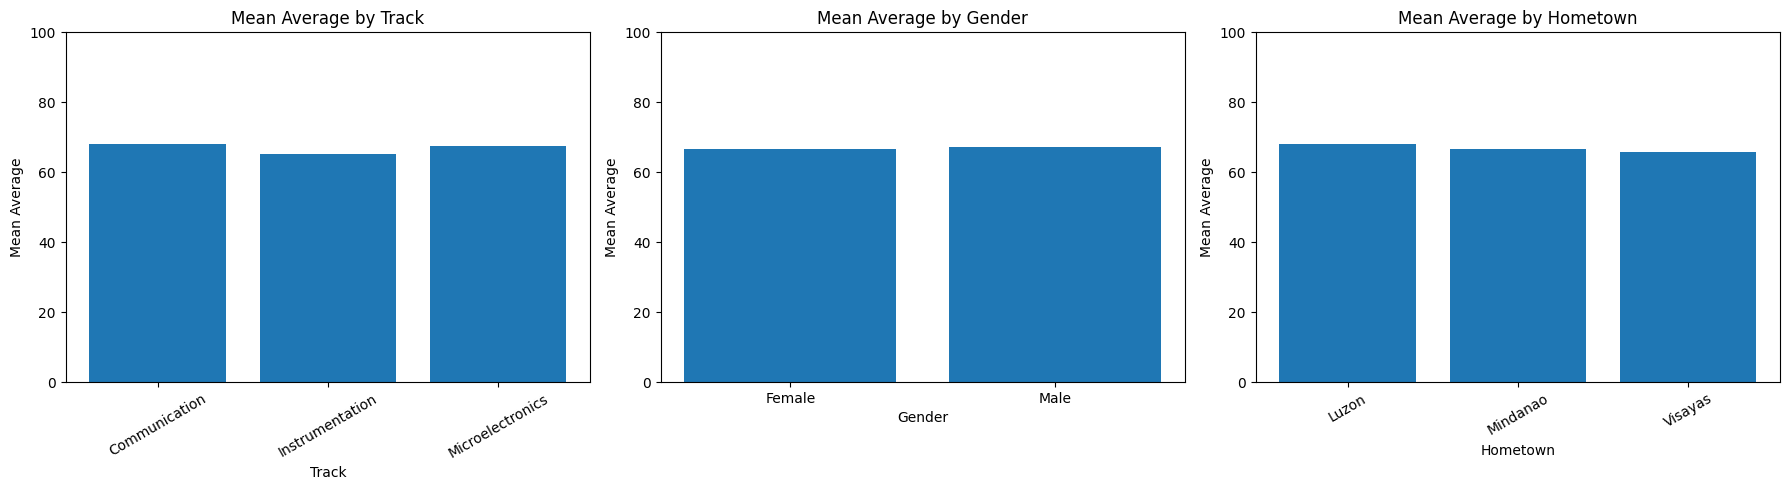

In [36]:
#Create three bar graphs in one figure

fig, axes = plt.subplots(1, 3, figsize = (18, 5))

# The Mean Average by Track
axes[0].bar(avg_track["Track"], avg_track["Average"])
axes[0].set_title("Mean Average by Track")
axes[0].set_xlabel("Track")
axes[0].set_ylabel("Mean Average")
axes[0].tick_params(axis = "x", rotation = 30)
axes[0].set_ylim(0, 100)

# The Mean Average by Gender
axes[1].bar(avg_gender["Gender"], avg_gender["Average"])
axes[1].set_title("Mean Average by Gender")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Mean Average")
axes[1].set_ylim(0, 100)

# The Mean Average by Hometown
axes[2].bar(avg_hometown["Hometown"], avg_hometown["Average"])
axes[2].set_title("Mean Average by Hometown")
axes[2].set_xlabel("Hometown")
axes[2].set_ylabel("Mean Average")
axes[2].tick_params(axis = "x", rotation = 30)
axes[2].set_ylim(0, 100)

# Adjust Spacing and Display the graphs
plt.tight_layout()
plt.show()

In [37]:
# Look for the category with the highest mean Average
highest_track = avg_track.loc[avg_track["Average"].idxmax()]
highest_gender = avg_gender.loc[avg_gender["Average"].idxmax()]
highest_hometown = avg_hometown.loc[avg_hometown["Average"].idxmax()]

# Display all of the three statements
print(
    f"{highest_track['Track']} has the highest mean Average"
    f"among the track categories at {highest_track['Average']:.2f}"
)
print(
    f"{highest_gender['Gender']} has the highest mean Average"
    f"among the gender categories at {highest_gender['Average']:.2f}"
)
print(
    f"{highest_hometown['Hometown']} has the highest mean Average"
    f"among the hometown categories at {highest_hometown['Average']:.2f}"
)

Communication has the highest mean Averageamong the track categories at 67.97
Male has the highest mean Averageamong the gender categories at 67.18
Luzon has the highest mean Averageamong the hometown categories at 68.08
